# CA local-interaction inference

This notebook implements the numerical procedure in `../writings/note_interaction.tex`. The zero-salt fitted random-wave ensemble is the empirical reference. The reusable calculations are in `cf_ca_interaction.py`; this notebook owns paths, parameter choices, execution, tables, and figures.

The default inference is the retained local-cell approximation. One sampled state represents a contour cell of length $\ell=1/k_{\rm eff}^{(0)}$, so
$$K_2^{\rm cell}\simeq\ell\kappa^2,\qquad K_4^{\rm cell}\simeq\ell\left[\frac{9}{64}\kappa^4-\frac{1}{24}(\kappa')^2-\frac{1}{24}(\kappa\tau)^2\right].$$
The fitted $\Delta c_2$ and $\Delta c_4$ are therefore effective local-cell coefficients unless the optional contour-integrated validation shows that neighboring-cell correlations are negligible.

## Configuration

In [1]:
from __future__ import annotations

import csv
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import cf_ca_interaction as interaction

HERE = Path.cwd().resolve()
if not (HERE / "cf_ca_interaction.py").exists():
    raise RuntimeError("Run this notebook from smpl/curvefit")
SMPL_ROOT = HERE.parent
PROJECT_ROOT = SMPL_ROOT.parent

FIT_SOURCE = "aniso"  # "iso" or "aniso"
FIT_SOURCES = {
    "iso": {
        "input_dir": HERE / "output" / "ca_iso",
        "pattern": "ca_*mM_gamma_radial_unguided_gamma_radial_isotropic_fit_parameters.csv",
    },
    "aniso": {
        "input_dir": HERE / "output" / "ca_aniso" / "gamma_OH2_best",
        "pattern": "ca_*mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv",
    },
}
if FIT_SOURCE not in FIT_SOURCES:
    raise ValueError(f"FIT_SOURCE must be one of {tuple(FIT_SOURCES)}")

# Set True only to regenerate the local conditional samples at 2**15 points.
# It is not needed to view existing files in output/ca_interaction_0mM_*.
PRODUCTION_MODE = True
LOCAL_SAMPLE_POWER = 15 if PRODUCTION_MODE else 10
LOCAL_RANDOM_SEED = 73129
CELL_LENGTH_MULTIPLIER = 1.0

# Production traces are generated separately by cf_ca_interaction_trace.ipynb.
# This notebook only loads a compatible cached trace when nonlocal work is enabled.
# Infer an effective Yukawa kernel for Delta V directly from Delta c2, Delta c4,
# then iterate D_delta, Delta F_nl, and the coefficients to self-consistency.
RUN_NONLOCAL_ANALYSIS = True
# Repeat every valid direct change-kernel calculation with increasing upper cutoffs.
RUN_TAIL_CONVERGENCE = False
# Compare local-cell coefficients with contour-integrated K2,K4. Requires a
# reference trace and TARGET_TRACES for every target concentration. Expensive.
RUN_CONTOUR_VALIDATION = False
# Legacy inline diagnostics are disabled because their compute-stage versions
# now live in cf_ca_interaction_compute.ipynb and export reusable artifacts.
RUN_CELL_LENGTH_DIAGNOSTICS = False
RUN_FLEXIBLE_MODEL_DIAGNOSTICS = False
# Very expensive: regenerated sample series plus hundreds of bootstrap refits.
RUN_REPLICATE_UNCERTAINTY = False
NONLOCAL_TAIL_RELATIVE_TOLERANCE = 0.01
NONLOCAL_DEPENDENCE_THRESHOLD = 0.01
# Require the inferred (g_delta/kref, D_delta*kref) to converge relatively.
NONLOCAL_KERNEL_RELATIVE_TOLERANCE = 0.01
# Warn when the finite-cutoff residual-force term exceeds this fraction of c4.
LINKED_K4_RESIDUAL_TOLERANCE = 0.01
NONLOCAL_CORRECTION_DEGREE = 3
NONLOCAL_MAXIMUM_ITERATIONS = 4
NONLOCAL_COEFFICIENT_TOLERANCE = 5e-3

# Exploratory zero-salt reference family for the conditional Yukawa plots.
# These bounds are not inferred from the local data; replace them with an
# experimentally or theoretically justified prior range when available.
CONDITIONAL_G0_OVER_KREF_BOUNDS = (100.0, 2000.0)
CONDITIONAL_D0_KREF_BOUNDS = (0.1, 1.0)
CONDITIONAL_REFERENCE_GRID_SIZE = 17
CONDITIONAL_ENVELOPE_STANDARD_DEVIATIONS = 1.0

OUTPUT_DIR = HERE / "output" / f"ca_interaction_refactored_0mM_{FIT_SOURCE}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 190, "axes.grid": True, "grid.alpha": 0.22})

## Fitted spectra and zero-salt reference

In [2]:
source = FIT_SOURCES[FIT_SOURCE]
fit_series = interaction.discover_fit_spectra(source["input_dir"], source["pattern"])
reference_spectrum = interaction.select_zero_salt_reference(fit_series)
REFERENCE_SALT = reference_spectrum.concentration_mM
REFERENCE_K_EFF = reference_spectrum.k_eff
CELL_LENGTH = CELL_LENGTH_MULTIPLIER / REFERENCE_K_EFF

fit_input_rows = [
    {
        "concentration_mM": row.concentration_mM,
        "k_eff": row.k_eff,
        "mean_k": row.mean_k,
        "r_sigma_k": row.r_sigma_k,
        "stretch_ignored": row.stretch_ignored,
        "source": str(row.source),
    }
    for row in fit_series
]
with (OUTPUT_DIR / "radial_fit_inputs.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(fit_input_rows[0]))
    writer.writeheader()
    writer.writerows(fit_input_rows)

print(f"fit source: {FIT_SOURCE}; conditions: {len(fit_series)}")
print(f"reference: {REFERENCE_SALT:g} mM; k_ref={REFERENCE_K_EFF:.8g} A^-1")
print(f"local cell length: {CELL_LENGTH:.8g} A")
print("affine stretch is recorded but omitted from the isotropic local-geometry model")

fit source: aniso; conditions: 8
reference: 0 mM; k_ref=0.052411293 A^-1
local cell length: 19.079858 A
affine stretch is recorded but omitted from the isotropic local-geometry model


## Conditional local geometry

The fitted gamma radial spectrum determines the derivative covariance conditioned on the two field zeros. Coarea weighting then gives the one-point distribution of $X=(\kappa,\kappa',\kappa\tau)$. Common Sobol normals are used for all salt conditions to reduce numerical differences between conditions.

In [3]:
local_samples = interaction.sample_local_geometry_series(
    fit_series,
    sample_power=LOCAL_SAMPLE_POWER,
    seed=LOCAL_RANDOM_SEED,
)
for row in fit_series:
    sample = local_samples[row.concentration_mM]
    print(
        f"{row.concentration_mM:6g} mM: n={len(sample.weights)}, "
        f"stable={sample.stable_fraction:.6f}, <J>={sample.mean_jacobian_dimensionless:.6f}"
    )

     0 mM: n=32768, stable=1.000000, <J>=0.666048
     1 mM: n=32768, stable=1.000000, <J>=0.666048
    10 mM: n=32768, stable=1.000000, <J>=0.666048
    24 mM: n=32768, stable=1.000000, <J>=0.666046
    40 mM: n=32768, stable=1.000000, <J>=0.666043
    55 mM: n=32768, stable=1.000000, <J>=0.666041
    70 mM: n=32768, stable=1.000000, <J>=0.666043
   100 mM: n=32768, stable=1.000000, <J>=0.666046


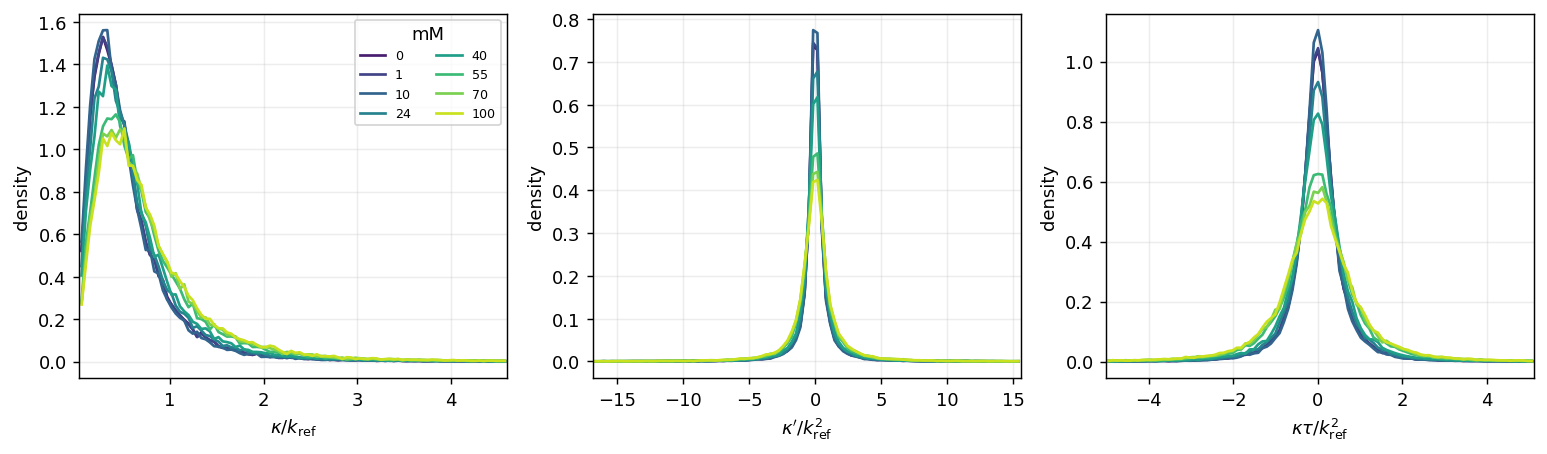

In [4]:
# Plot a common central support so rare Sobol-tail samples do not flatten the visible densities.
geometry_specs = (
    ("kappa", REFERENCE_K_EFF, r"$\kappa/k_{\rm ref}$"),
    ("kappa_prime", REFERENCE_K_EFF**2, r"$\kappa'/k_{\rm ref}^2$"),
    ("kappa_tau", REFERENCE_K_EFF**2, r"$\kappa\tau/k_{\rm ref}^2$"),
)
geometry_ranges = {}
for name, scale, _ in geometry_specs:
    bounds = np.array([
        interaction.weighted_quantile(getattr(sample, name) / scale, [0.005, 0.995], sample.weights)
        for sample in local_samples.values()
    ])
    geometry_ranges[name] = (np.min(bounds[:, 0]), np.max(bounds[:, 1]))

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6))
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(fit_series)))
for color, row in zip(colors, fit_series):
    sample = local_samples[row.concentration_mM]
    for axis, (name, scale, label) in zip(axes, geometry_specs):
        histogram, edges = np.histogram(
            getattr(sample, name) / scale,
            bins=100,
            range=geometry_ranges[name],
            weights=sample.weights,
            density=True,
        )
        axis.plot(0.5 * (edges[:-1] + edges[1:]), histogram, color=color, label=f"{row.concentration_mM:g}")
        axis.set(xlabel=label, ylabel="density", xlim=geometry_ranges[name])
axes[0].legend(title="mM", fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "local_geometry_distributions.png")
plt.show()

## Default local-cell reweighting

For each target condition, the zero-salt reference is tilted by $\exp[-\Delta c_2K_2^{\rm cell}-\Delta c_4K_4^{\rm cell}]$. No $X$-dependent nonlocal correction is inserted unless the separate target-minus-reference potential analysis below is enabled and supplies one. The saved coefficients use the note's $c_4$ notation.

In [5]:
reference_sample = local_samples[REFERENCE_SALT]
fit_results = {}
coefficient_rows = []
quality_rows = []
rng = np.random.default_rng(9123)
train_mask = rng.random(len(reference_sample.weights)) < 0.67
test_mask = ~train_mask

for row in fit_series:
    concentration = row.concentration_mM
    if concentration == REFERENCE_SALT:
        coefficient_rows.append({
            "concentration_mM": concentration,
            "delta_c2_kref": 0.0,
            "delta_c2_kref_se_naive": 0.0,
            "delta_c4_kref3": 0.0,
            "delta_c4_kref3_se_naive": 0.0,
            "target_mass_retained": 1.0,
            "reference_effective_fraction": 1.0,
            "local_cell_length_times_kref": CELL_LENGTH * REFERENCE_K_EFF,
        })
        continue
    target = local_samples[concentration]
    result = interaction.fit_local_cell_reweighting(
        reference_sample,
        target,
        REFERENCE_K_EFF,
        cell_length=CELL_LENGTH,
    )
    fit_results[concentration] = result
    errors = result.standard_errors
    coefficient_rows.append({
        "concentration_mM": concentration,
        "delta_c2_kref": result.delta_c2_kref,
        "delta_c2_kref_se_naive": errors[0],
        "delta_c4_kref3": result.delta_c4_kref3,
        "delta_c4_kref3_se_naive": errors[1],
        "target_mass_retained": result.target_mass_retained,
        "reference_effective_fraction": result.reference_effective_fraction,
        "local_cell_length_times_kref": CELL_LENGTH * REFERENCE_K_EFF,
    })
    heldout = interaction.fit_local_cell_reweighting(
        reference_sample,
        target,
        REFERENCE_K_EFF,
        cell_length=CELL_LENGTH,
        reference_mask=train_mask,
        target_mask=train_mask,
    )
    predicted = interaction.reweighted_reference_weights(
        reference_sample,
        heldout,
        REFERENCE_K_EFF,
        cell_length=CELL_LENGTH,
    )
    predicted_test = predicted[test_mask]
    predicted_test /= predicted_test.sum()
    distances = {
        name: interaction.weighted_ks_distance(
            getattr(target, name)[test_mask],
            target.weights[test_mask],
            getattr(reference_sample, name)[test_mask],
            predicted_test,
        )
        for name in ("kappa", "kappa_prime", "kappa_tau")
    }
    quality_rows.append({"concentration_mM": concentration, **{f"KS_{key}": value for key, value in distances.items()}, "KS_mean": np.mean(list(distances.values()))})

with (OUTPUT_DIR / "effective_local_cell_coefficients.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(coefficient_rows[0]))
    writer.writeheader(); writer.writerows(coefficient_rows)
if quality_rows:
    with (OUTPUT_DIR / "heldout_reconstruction_quality.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(quality_rows[0]))
        writer.writeheader(); writer.writerows(quality_rows)

coefficient_rows

[{'concentration_mM': 0.0,
  'delta_c2_kref': 0.0,
  'delta_c2_kref_se_naive': 0.0,
  'delta_c4_kref3': 0.0,
  'delta_c4_kref3_se_naive': 0.0,
  'target_mass_retained': 1.0,
  'reference_effective_fraction': 1.0,
  'local_cell_length_times_kref': 1.0},
 {'concentration_mM': 1.0,
  'delta_c2_kref': 0.0031918527162692672,
  'delta_c2_kref_se_naive': np.float64(0.01051206590179446),
  'delta_c4_kref3': -0.0015395450425696846,
  'delta_c4_kref3_se_naive': np.float64(0.009806296733399498),
  'target_mass_retained': 0.9940241140741966,
  'reference_effective_fraction': 0.6801612899769346,
  'local_cell_length_times_kref': 1.0},
 {'concentration_mM': 10.0,
  'delta_c2_kref': 0.03730715679638097,
  'delta_c2_kref_se_naive': np.float64(0.010792100745737988),
  'delta_c4_kref3': -0.01807104796349279,
  'delta_c4_kref3_se_naive': np.float64(0.010102733261042012),
  'target_mass_retained': 0.994173347730398,
  'reference_effective_fraction': 0.6718224333426436,
  'local_cell_length_times_kref': 1.

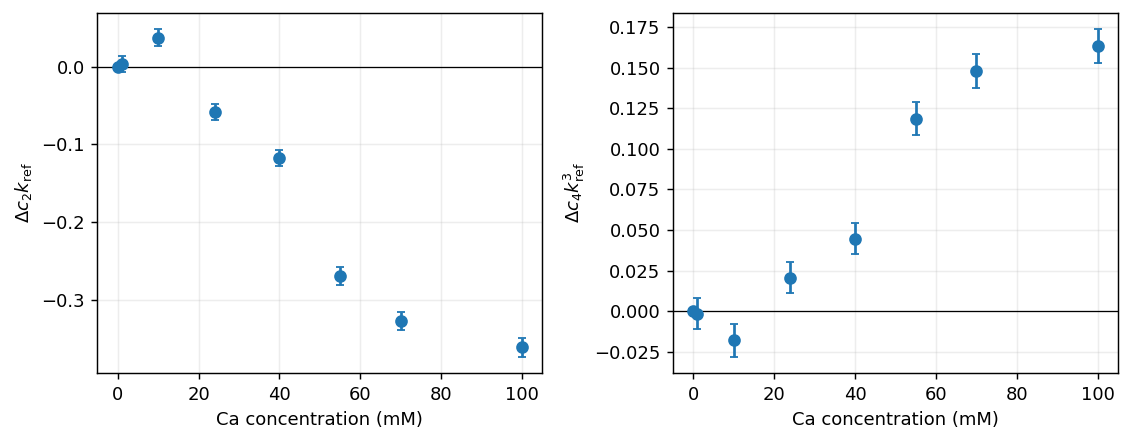

In [6]:
salt = np.array([row["concentration_mM"] for row in coefficient_rows])
delta_c2 = np.array([row["delta_c2_kref"] for row in coefficient_rows])
delta_c4 = np.array([row["delta_c4_kref3"] for row in coefficient_rows])
error_c2 = np.array([row["delta_c2_kref_se_naive"] for row in coefficient_rows])
error_c4 = np.array([row["delta_c4_kref3_se_naive"] for row in coefficient_rows])
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.5), sharex=True)
axes[0].errorbar(salt, delta_c2, yerr=error_c2, marker="o", linestyle="none", capsize=2)
axes[1].errorbar(salt, delta_c4, yerr=error_c4, marker="o", linestyle="none", capsize=2)
for axis, label in zip(axes, (r"$\Delta c_2 k_{\rm ref}$", r"$\Delta c_4 k_{\rm ref}^3$")):
    axis.axhline(0, color="k", lw=0.7); axis.set(xlabel="Ca concentration (mM)", ylabel=label)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "effective_c2_c4_changes.png"); plt.show()

## $\kappa$ and $\tau$ reconstruction from $\Delta c_2,\Delta c_4$

For each nonzero salt condition, the solid curve is the target local distribution and the dashed curve is the zero-salt reference reweighted with the linked $\Delta c_2,\Delta c_4$ model. Both are restricted to the common fit support. This is a legacy in-sample adequacy diagnostic, not the final reconstruction report. The final target/flexible/linked comparison is generated by `cf_ca_interaction_results.ipynb` from artifacts prepared by `cf_ca_interaction_compute.ipynb`.

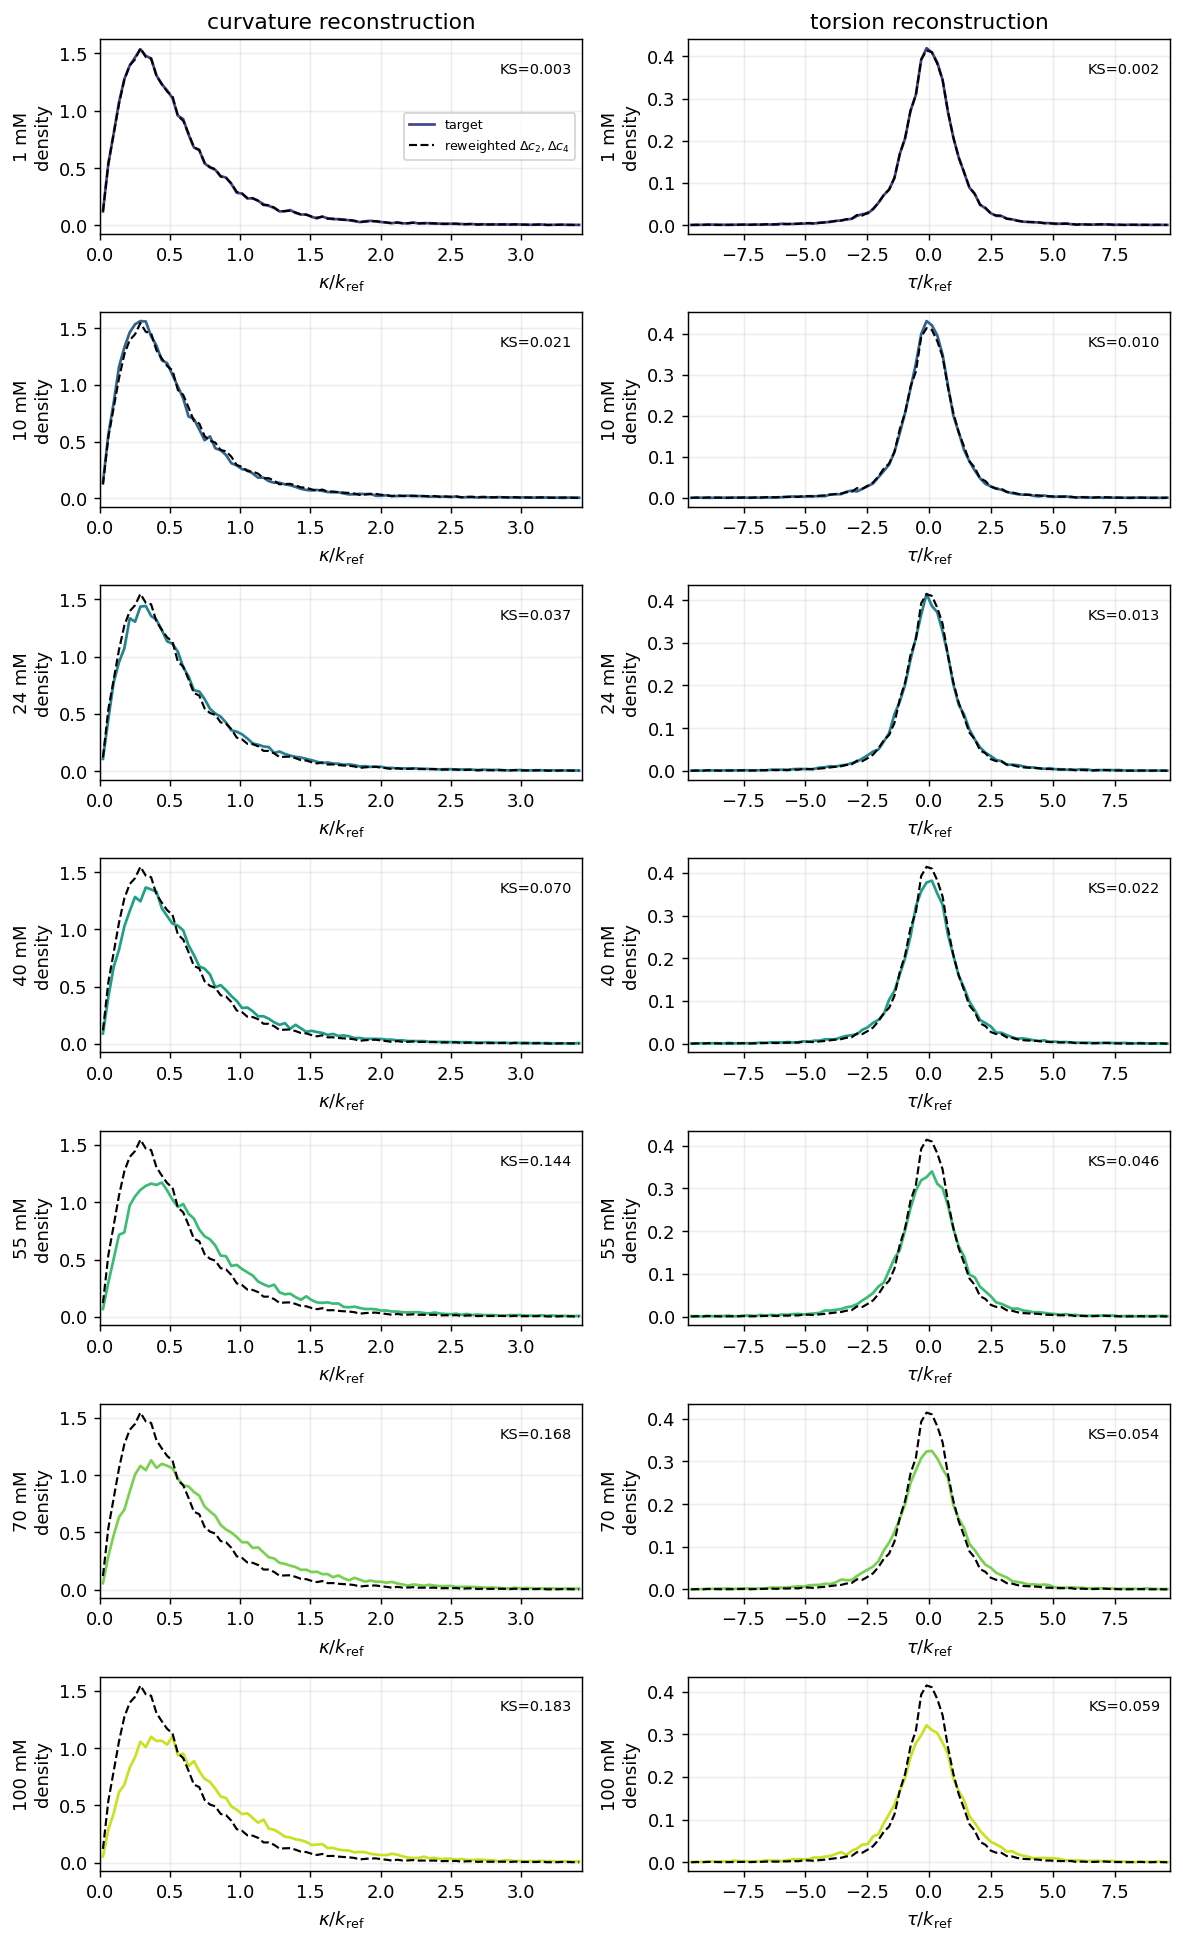

[{'concentration_mM': 1.0,
  'KS_kappa': 0.002927657504243064,
  'KS_tau': 0.0015548309306490093},
 {'concentration_mM': 10.0,
  'KS_kappa': 0.021487396870422226,
  'KS_tau': 0.009621936447790636},
 {'concentration_mM': 24.0,
  'KS_kappa': 0.03679567350610602,
  'KS_tau': 0.012590614813911563},
 {'concentration_mM': 40.0,
  'KS_kappa': 0.07032750571074942,
  'KS_tau': 0.022334630440695058},
 {'concentration_mM': 55.0,
  'KS_kappa': 0.144251920347726,
  'KS_tau': 0.04640746610189665},
 {'concentration_mM': 70.0,
  'KS_kappa': 0.16810196760774798,
  'KS_tau': 0.05423621533118317},
 {'concentration_mM': 100.0,
  'KS_kappa': 0.1834576459794614,
  'KS_tau': 0.059370221153261626}]

In [7]:
color_by_salt = {row.concentration_mM: color for row, color in zip(fit_series, colors)}
reference_tau, reference_tau_keep = interaction.torsion_from_local_geometry(reference_sample)
reference_tau_full = np.full(len(reference_sample.weights), np.nan)
reference_tau_full[reference_tau_keep] = reference_tau / REFERENCE_K_EFF
reconstruction_distributions = {}
reconstruction_quality_rows = []

for concentration, result in fit_results.items():
    target = local_samples[concentration]
    predicted_weights = interaction.reweighted_reference_weights(
        reference_sample, result, REFERENCE_K_EFF, cell_length=CELL_LENGTH
    )
    target_tau, target_tau_keep = interaction.torsion_from_local_geometry(target)
    target_tau_full = np.full(len(target.weights), np.nan)
    target_tau_full[target_tau_keep] = target_tau / REFERENCE_K_EFF

    variable_data = {}
    for name, reference_values, target_values, reference_valid, target_valid in (
        ("kappa", reference_sample.kappa / REFERENCE_K_EFF, target.kappa / REFERENCE_K_EFF, np.ones(len(reference_sample.weights), dtype=bool), np.ones(len(target.weights), dtype=bool)),
        ("tau", reference_tau_full, target_tau_full, reference_tau_keep, target_tau_keep),
    ):
        reference_keep = result.reference_keep & reference_valid
        target_keep = result.target_keep & target_valid
        reference_values_kept = reference_values[reference_keep]
        target_values_kept = target_values[target_keep]
        reference_weights_kept = predicted_weights[reference_keep]
        target_weights_kept = target.weights[target_keep]
        reference_weights_kept /= reference_weights_kept.sum()
        target_weights_kept /= target_weights_kept.sum()
        ks = interaction.weighted_ks_distance(
            target_values_kept, target_weights_kept,
            reference_values_kept, reference_weights_kept,
        )
        variable_data[name] = (reference_values_kept, reference_weights_kept, target_values_kept, target_weights_kept, ks)
    reconstruction_distributions[concentration] = variable_data
    reconstruction_quality_rows.append({
        "concentration_mM": concentration,
        "KS_kappa": variable_data["kappa"][4],
        "KS_tau": variable_data["tau"][4],
    })

reconstruction_ranges = {}
for name in ("kappa", "tau"):
    bounds = []
    for variable_data in reconstruction_distributions.values():
        reference_values, reference_weights, target_values, target_weights, _ = variable_data[name]
        bounds.append(interaction.weighted_quantile(reference_values, [0.005, 0.995], reference_weights))
        bounds.append(interaction.weighted_quantile(target_values, [0.005, 0.995], target_weights))
    bounds = np.asarray(bounds)
    if name == "kappa":
        reconstruction_ranges[name] = (0.0, np.max(bounds[:, 1]))
    else:
        limit = np.max(np.abs(bounds))
        reconstruction_ranges[name] = (-limit, limit)

condition_count = len(reconstruction_distributions)
fig, axes = plt.subplots(condition_count, 2, figsize=(9.2, 2.15 * condition_count), squeeze=False)
for row_index, (concentration, variable_data) in enumerate(reconstruction_distributions.items()):
    color = color_by_salt[concentration]
    for column_index, (name, xlabel) in enumerate((("kappa", r"$\kappa/k_{\rm ref}$"), ("tau", r"$\tau/k_{\rm ref}$"))):
        axis = axes[row_index, column_index]
        reference_values, reference_weights, target_values, target_weights, ks = variable_data[name]
        histogram_range = reconstruction_ranges[name]
        target_histogram, edges = np.histogram(target_values, bins=90, range=histogram_range, weights=target_weights, density=True)
        predicted_histogram, _ = np.histogram(reference_values, bins=edges, weights=reference_weights, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        axis.plot(centers, target_histogram, color=color, lw=1.5, label="target")
        axis.plot(centers, predicted_histogram, color="k", lw=1.2, ls="--", label=r"reweighted $\Delta c_2,\Delta c_4$")
        axis.text(0.98, 0.88, f"KS={ks:.3f}", transform=axis.transAxes, ha="right", va="top", fontsize=8)
        axis.set(xlabel=xlabel, ylabel=f"{concentration:g} mM\ndensity", xlim=histogram_range)
        if row_index == 0:
            axis.set_title("curvature reconstruction" if name == "kappa" else "torsion reconstruction")
axes[0, 0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "local_kappa_tau_linked_diagnostic_inline.png")
plt.show()

with (OUTPUT_DIR / "local_kappa_tau_linked_quality_inline.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(reconstruction_quality_rows[0]))
    writer.writeheader(); writer.writerows(reconstruction_quality_rows)
reconstruction_quality_rows

## Cell-length and flexible-model diagnostics

In [8]:
cell_length_rows = []
for concentration, target in (local_samples.items() if RUN_CELL_LENGTH_DIAGNOSTICS else []):
    if concentration == REFERENCE_SALT:
        continue
    for length, result in interaction.local_cell_length_sensitivity(
        reference_sample,
        target,
        REFERENCE_K_EFF,
        np.array([0.75, 1.0, 1.25]) / REFERENCE_K_EFF,
    ):
        cell_length_rows.append({
            "concentration_mM": concentration,
            "cell_length_times_kref": length * REFERENCE_K_EFF,
            "delta_c2_kref": result.delta_c2_kref,
            "delta_c4_kref3": result.delta_c4_kref3,
        })
if cell_length_rows:
    with (OUTPUT_DIR / "local_cell_length_sensitivity.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(cell_length_rows[0]))
        writer.writeheader(); writer.writerows(cell_length_rows)

flexible_rows = []
for concentration, target in (local_samples.items() if RUN_FLEXIBLE_MODEL_DIAGNOSTICS else []):
    if concentration == REFERENCE_SALT:
        continue
    flexible = interaction.fit_flexible_density_ratio(
        reference_sample, target, REFERENCE_K_EFF, degree=4,
        reference_mask=train_mask, target_mask=train_mask,
    )
    log_ratio = flexible.log_ratio(reference_sample.state, REFERENCE_K_EFF)
    log_ratio -= np.max(log_ratio[test_mask])
    flexible_weights = reference_sample.weights[test_mask] * np.exp(np.maximum(log_ratio[test_mask], -60.0))
    flexible_weights /= flexible_weights.sum()
    flexible_distances = {
        name: interaction.weighted_ks_distance(
            getattr(target, name)[test_mask], target.weights[test_mask],
            getattr(reference_sample, name)[test_mask], flexible_weights,
        )
        for name in ("kappa", "kappa_prime", "kappa_tau")
    }
    independent = interaction.fit_independent_invariant_density_ratio(
        reference_sample, target, REFERENCE_K_EFF,
        reference_mask=train_mask, target_mask=train_mask,
    )
    independent_log_ratio = independent.log_ratio(reference_sample, REFERENCE_K_EFF)
    independent_log_ratio -= np.max(independent_log_ratio[test_mask])
    independent_weights = reference_sample.weights[test_mask] * np.exp(np.maximum(independent_log_ratio[test_mask], -60.0))
    independent_weights /= independent_weights.sum()
    independent_distances = {
        name: interaction.weighted_ks_distance(
            getattr(target, name)[test_mask], target.weights[test_mask],
            getattr(reference_sample, name)[test_mask], independent_weights,
        )
        for name in ("kappa", "kappa_prime", "kappa_tau")
    }
    quality_row = next(row for row in quality_rows if row["concentration_mM"] == concentration)
    quality_row.update({f"KS_{name}_flexible": value for name, value in flexible_distances.items()})
    quality_row["KS_mean_flexible"] = np.mean(list(flexible_distances.values()))
    quality_row.update({f"KS_{name}_independent": value for name, value in independent_distances.items()})
    quality_row["KS_mean_independent"] = np.mean(list(independent_distances.values()))
    flexible_rows.append({"concentration_mM": concentration, "flexible_loss": flexible.loss, "flexible_success": flexible.success, "independent_loss": independent.loss, "independent_success": independent.success})
with (OUTPUT_DIR / "heldout_reconstruction_quality.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(quality_rows[0]))
    writer.writeheader(); writer.writerows(quality_rows)

replicate_uncertainty = {}
if RUN_REPLICATE_UNCERTAINTY:
    replicate_samples = [interaction.sample_local_geometry_series(fit_series, sample_power=13, seed=seed) for seed in (101, 211, 307, 401, 503, 601)]
    for concentration in fit_results:
        reference_replicates = [samples[REFERENCE_SALT] for samples in replicate_samples]
        target_replicates = [samples[concentration] for samples in replicate_samples]
        replicate_uncertainty[concentration] = interaction.bootstrap_local_cell_replicates(
            reference_replicates, target_replicates, REFERENCE_K_EFF, CELL_LENGTH,
            bootstrap_samples=400, seed=7103,
        )
flexible_rows

[{'concentration_mM': 1.0,
  'flexible_loss': 0.6931419950084484,
  'flexible_success': True,
  'independent_loss': 0.6931452835516833,
  'independent_success': False},
 {'concentration_mM': 10.0,
  'flexible_loss': 0.6924399074152225,
  'flexible_success': True,
  'independent_loss': 0.692887254231883,
  'independent_success': False},
 {'concentration_mM': 24.0,
  'flexible_loss': 0.6910416443035384,
  'flexible_success': True,
  'independent_loss': 0.6924559304157959,
  'independent_success': True},
 {'concentration_mM': 40.0,
  'flexible_loss': 0.684830051639716,
  'flexible_success': True,
  'independent_loss': 0.6904182476846314,
  'independent_success': True},
 {'concentration_mM': 55.0,
  'flexible_loss': 0.6565953194053934,
  'flexible_success': True,
  'independent_loss': 0.6797387966363626,
  'independent_success': False},
 {'concentration_mM': 70.0,
  'flexible_loss': 0.6421922910502648,
  'flexible_success': True,
  'independent_loss': 0.6738720759572352,
  'independent_suc

## Direct nonlocal interaction-change correction

The zero-salt trace supplies the complementary chord geometry. The inferred $\Delta c_2,\Delta c_4$ determine a signed effective Yukawa representation of $\Delta V$ when the two moments have the same sign. Its nonlocal energy is evaluated directly on reference chords. After estimating $\Delta F_{\rm nl}$, the moments and $(g_\Delta,D_\Delta)$ are re-inferred until both the coefficients and kernel parameters converge. No absolute reference or target interaction is introduced.

In [9]:
trace_config = interaction.TraceConfig(
    grid_size=64,
    num_blocks=1,
    num_modes=256,
    trace_k0=5.0,
    random_seed=894894,
    seed_spacing=0.35,
    q_spacing=0.08,
)
trace_cache = OUTPUT_DIR / "reference_isotropic_trace.npz"
reference_trace = interaction.load_trace_cache(trace_cache, trace_config, reference_spectrum)
print("reference trace:", "available" if reference_trace is not None else "not cached; run cf_ca_interaction_trace.ipynb")
analysis_metadata = [
    {"name": "fit_source", "value": FIT_SOURCE},
    {"name": "reference_concentration_mM", "value": REFERENCE_SALT},
    {"name": "reference_k_eff", "value": REFERENCE_K_EFF},
    {"name": "cell_length", "value": CELL_LENGTH},
    {"name": "local_sample_power", "value": LOCAL_SAMPLE_POWER},
    {"name": "local_random_seed", "value": LOCAL_RANDOM_SEED},
    {"name": "trace_grid_size", "value": trace_config.grid_size},
    {"name": "trace_num_modes", "value": trace_config.num_modes},
    {"name": "trace_q_spacing", "value": trace_config.q_spacing},
    {"name": "trace_random_seed", "value": trace_config.random_seed},
    {"name": "nonlocal_q_min", "value": 1.0},
    {"name": "nonlocal_q_max_initial", "value": 8.0},
    {"name": "nonlocal_dependence_threshold", "value": NONLOCAL_DEPENDENCE_THRESHOLD},
    {"name": "nonlocal_kernel_relative_tolerance", "value": NONLOCAL_KERNEL_RELATIVE_TOLERANCE},
    {"name": "linked_K4_residual_tolerance", "value": LINKED_K4_RESIDUAL_TOLERANCE},
    {"name": "nonlocal_correction_degree", "value": NONLOCAL_CORRECTION_DEGREE},
    {"name": "nonlocal_maximum_iterations", "value": NONLOCAL_MAXIMUM_ITERATIONS},
    {"name": "nonlocal_coefficient_tolerance", "value": NONLOCAL_COEFFICIENT_TOLERANCE},
    {"name": "conditional_g0_over_kref_bounds", "value": CONDITIONAL_G0_OVER_KREF_BOUNDS},
    {"name": "conditional_d0_kref_bounds", "value": CONDITIONAL_D0_KREF_BOUNDS},
    {"name": "conditional_reference_grid_size", "value": CONDITIONAL_REFERENCE_GRID_SIZE},
    {"name": "conditional_envelope_standard_deviations", "value": CONDITIONAL_ENVELOPE_STANDARD_DEVIATIONS},
    {"name": "nonlocal_tail_relative_tolerance", "value": NONLOCAL_TAIL_RELATIVE_TOLERANCE},
    {"name": "python", "value": platform.python_version()},
    {"name": "numpy", "value": np.__version__},
]
with (OUTPUT_DIR / "analysis_metadata.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=("name", "value"))
    writer.writeheader(); writer.writerows(analysis_metadata)

direct_nonlocal_results = {}
direct_nonlocal_rows = []
if RUN_NONLOCAL_ANALYSIS:
    if reference_trace is None:
        raise RuntimeError(
            "Direct interaction-change analysis requires zero-salt chord geometry. "
            "Run cf_ca_interaction_trace.ipynb once to create a compatible cache."
        )
    config = interaction.NonlocalConfig.from_dimensionless(reference_trace.k_eff, q_max=8.0)
    for concentration, initial_fit in fit_results.items():
        base_row = {"concentration_mM": concentration, "local_delta_c2_kref": initial_fit.delta_c2_kref, "local_delta_c4_kref3": initial_fit.delta_c4_kref3}
        try:
            result = interaction.fit_direct_nonlocal_change_correction(
                reference_trace, reference_sample, local_samples[concentration],
                REFERENCE_K_EFF, initial_fit.delta_c2_kref,
                initial_fit.delta_c4_kref3, config, cell_length=CELL_LENGTH,
                maximum_iterations=NONLOCAL_MAXIMUM_ITERATIONS,
                coefficient_tolerance=NONLOCAL_COEFFICIENT_TOLERANCE,
                dependence_threshold=NONLOCAL_DEPENDENCE_THRESHOLD,
                correction_degree=NONLOCAL_CORRECTION_DEGREE,
                linked_residual_tolerance=LINKED_K4_RESIDUAL_TOLERANCE,
                kernel_relative_tolerance=NONLOCAL_KERNEL_RELATIVE_TOLERANCE,
            )
        except (ValueError, RuntimeError) as error:
            direct_nonlocal_rows.append({**base_row, "change_kernel_available": False, "status": str(error)})
            print(f"{concentration:g} mM: no one-Yukawa change kernel — {error}")
            continue
        direct_nonlocal_results[concentration] = result
        direct_nonlocal_rows.append({
            **base_row,
            "change_kernel_available": True,
            "status": "converged" if result.converged else "not converged",
            "g_delta_over_kref": result.g_delta_over_kref,
            "D_delta_kref": result.d_delta_kref,
            "initial_D_delta_kref": result.kernel_history[0, 1],
            "iterations": len(result.coefficient_history) - 1,
            "svd_retained_fraction": result.dependence.svd_retained_fraction,
            "cv_R2": result.dependence.mean_r2,
            "dependent": result.dependence.dependent,
            "corrected_delta_c2_kref": result.corrected_fit.delta_c2_kref,
            "corrected_delta_c4_kref3": result.corrected_fit.delta_c4_kref3,
            "linked_K4_residual_fraction": result.linked_check.relative_magnitude,
            "linked_K4_adequate": result.linked_check.adequate,
        })
        print(f"{concentration:g} mM: D_delta*kref {result.kernel_history[0,1]:.4g} -> {result.d_delta_kref:.4g}, converged={result.converged}")
if direct_nonlocal_rows:
    fieldnames = sorted({key for row in direct_nonlocal_rows for key in row})
    with (OUTPUT_DIR / "direct_interaction_change_nonlocal.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader(); writer.writerows(direct_nonlocal_rows)

reference trace: available
1 mM: no one-Yukawa change kernel — one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign
10 mM: no one-Yukawa change kernel — one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign
24 mM: no one-Yukawa change kernel — one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign
40 mM: no one-Yukawa change kernel — one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign
55 mM: no one-Yukawa change kernel — one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign
70 mM: no one-Yukawa change kernel — one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign
100 mM: no one-Yukawa change kernel — one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign


## Deferred production convergence and contour validation

In [10]:
tail_rows = []
if RUN_TAIL_CONVERGENCE:
    if reference_trace is None or not direct_nonlocal_results:
        raise RuntimeError("No admissible direct interaction-change result is available for tail convergence")
    for concentration, result in direct_nonlocal_results.items():
        base = interaction.NonlocalConfig.from_dimensionless(reference_trace.k_eff, q_max=4.0)
        zero_change = interaction.YukawaChangeKernel(0.0, result.change_kernel.screening_length)
        rows = interaction.nonlocal_tail_convergence(
            reference_trace, result.change_kernel, zero_change, base,
            np.array([4.0, 6.0, 8.0, 12.0]) / reference_trace.k_eff,
        )
        tail_rows.extend({"concentration_mM": concentration, **row} for row in rows)
        if not np.isfinite(rows[-1]["relative_mean_increment"]) or rows[-1]["relative_mean_increment"] > NONLOCAL_TAIL_RELATIVE_TOLERANCE:
            print(f"WARNING: interaction-change tail is not converged for {concentration:g} mM")

contour_validation_rows = []
TARGET_TRACES = {}  # production traces keyed by concentration
if RUN_CONTOUR_VALIDATION:
    if reference_trace is None or not TARGET_TRACES:
        raise RuntimeError("Reference and target traces are required")
    reference_observables = []
    for state in interaction.trace_local_state(reference_trace):
        s = np.arange(len(state)) * reference_trace.physical_spacing
        reference_observables.append(interaction.contour_observables(state[:, 0], state[:, 1], state[:, 2], s))
    reference_observables = np.asarray(reference_observables)
    for concentration, target_trace in TARGET_TRACES.items():
        target_observables = []
        for state in interaction.trace_local_state(target_trace):
            s = np.arange(len(state)) * target_trace.physical_spacing
            target_observables.append(interaction.contour_observables(state[:, 0], state[:, 1], state[:, 2], s))
        target_observables = np.asarray(target_observables)
        result = interaction.fit_contour_reweighting(
            reference_observables,
            target_observables,
            np.ones(len(reference_observables)),
            np.ones(len(target_observables)),
            REFERENCE_K_EFF,
        )
        local_result = fit_results.get(concentration)
        contour_validation_rows.append({
            "concentration_mM": concentration,
            "delta_c2_kref_contour": result.delta_c2_kref,
            "delta_c4_kref3_contour": result.delta_c4_kref3,
            "delta_c2_kref_cell": np.nan if local_result is None else local_result.delta_c2_kref,
            "delta_c4_kref3_cell": np.nan if local_result is None else local_result.delta_c4_kref3,
            "delta_c2_correlation_shift": np.nan if local_result is None else result.delta_c2_kref - local_result.delta_c2_kref,
            "delta_c4_correlation_shift": np.nan if local_result is None else result.delta_c4_kref3 - local_result.delta_c4_kref3,
        })

print("tail convergence rows:", len(tail_rows))
print("contour validation rows:", len(contour_validation_rows))
print("trace convergence: run cf_ca_interaction_trace.ipynb")

tail convergence rows: 0
contour validation rows: 0
trace convergence rows: 0


## Effective Yukawa interaction-change mapping

The finite-cutoff equations for the effective change kernel require nonzero $\Delta c_2$ and $\Delta c_4$ with the same sign because $f_2,f_4>0$. Conditions that fail this test do not admit a real one-Yukawa continuation and are reported without assigning $D_\Delta$. For admissible conditions, the displayed final parameters use the self-consistent nonlocal result when available.

No nonzero condition admits a single effective Yukawa change: Delta c2 and Delta c4 have opposite signs.


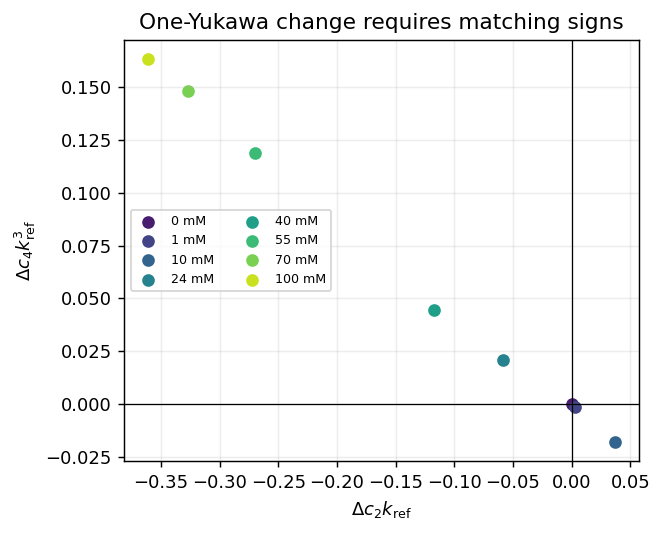

[{'concentration_mM': np.float64(0.0),
  'delta_c2_kref': np.float64(0.0),
  'delta_c4_kref3': np.float64(0.0),
  'change_kernel_available': False,
  'status': 'zero change does not identify D_delta'},
 {'concentration_mM': np.float64(1.0),
  'delta_c2_kref': np.float64(0.0031918527162692672),
  'delta_c4_kref3': np.float64(-0.0015395450425696846),
  'change_kernel_available': False,
  'status': 'one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign'},
 {'concentration_mM': np.float64(10.0),
  'delta_c2_kref': np.float64(0.03730715679638097),
  'delta_c4_kref3': np.float64(-0.01807104796349279),
  'change_kernel_available': False,
  'status': 'one effective Yukawa change requires Delta c2 and Delta c4 to have the same sign'},
 {'concentration_mM': np.float64(24.0),
  'delta_c2_kref': np.float64(-0.058097014652597874),
  'delta_c4_kref3': np.float64(0.020581254880049218),
  'change_kernel_available': False,
  'status': 'one effective Yukawa change requires Del

In [11]:
# Direct one-Yukawa continuation of the inferred interaction change.
interaction_change_rows = []
for index, concentration in enumerate(salt):
    row = {"concentration_mM": concentration, "delta_c2_kref": delta_c2[index], "delta_c4_kref3": delta_c4[index]}
    if concentration == REFERENCE_SALT:
        interaction_change_rows.append({**row, "change_kernel_available": False, "status": "zero change does not identify D_delta"})
        continue
    try:
        g_initial, d_initial = interaction.solve_yukawa_change(delta_c2[index], delta_c4[index], CELL_LENGTH * REFERENCE_K_EFF)
        se_g, se_d = interaction.yukawa_change_uncertainty(delta_c2[index], delta_c4[index], fit_results[float(concentration)].covariance, CELL_LENGTH * REFERENCE_K_EFF)
    except ValueError as error:
        interaction_change_rows.append({**row, "change_kernel_available": False, "status": str(error)})
        continue
    result = direct_nonlocal_results.get(float(concentration))
    g_final = float(g_initial) if result is None else result.g_delta_over_kref
    d_final = float(d_initial) if result is None else result.d_delta_kref
    kernel = interaction.YukawaChangeKernel(g_final * REFERENCE_K_EFF, d_final / REFERENCE_K_EFF)
    linked_check = interaction.linked_fourth_order_check(kernel, CELL_LENGTH, LINKED_K4_RESIDUAL_TOLERANCE, emit_warning=False)
    interaction_change_rows.append({**row, "change_kernel_available": True, "status": "local initialization" if result is None else ("self-consistent" if result.converged else "not converged"), "g_delta_over_kref_initial": float(g_initial), "D_delta_kref_initial": float(d_initial), "g_delta_over_kref": g_final, "D_delta_kref": d_final, "g_delta_over_kref_se_naive": se_g, "D_delta_kref_se_naive": se_d, "linked_K4_residual_fraction": linked_check.relative_magnitude, "linked_K4_adequate": linked_check.adequate})

available_change_rows = [row for row in interaction_change_rows if row["change_kernel_available"]]
if not available_change_rows:
    print("No nonzero condition admits a single effective Yukawa change: Delta c2 and Delta c4 have opposite signs.")

fig, axis = plt.subplots(figsize=(5.2, 4.2))
axis.axhline(0.0, color="k", lw=0.7); axis.axvline(0.0, color="k", lw=0.7)
for color, concentration, value2, value4 in zip(colors, salt, delta_c2, delta_c4):
    axis.scatter(value2, value4, color=color, label=f"{concentration:g} mM")
axis.set(xlabel=r"$\Delta c_2 k_{\rm ref}$", ylabel=r"$\Delta c_4 k_{\rm ref}^3$", title="One-Yukawa change requires matching signs")
axis.legend(fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "interaction_change_yukawa_admissibility.png"); plt.show()

if available_change_rows:
    change_salt = np.array([row["concentration_mM"] for row in available_change_rows])
    change_g = np.array([row["g_delta_over_kref"] for row in available_change_rows])
    change_d = np.array([row["D_delta_kref"] for row in available_change_rows])
    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.5), sharex=True)
    axes[0].plot(change_salt, change_g, "o"); axes[1].plot(change_salt, change_d, "o", color="C1")
    axes[0].set(xlabel="Ca concentration (mM)", ylabel=r"$g_\Delta/k_{\rm ref}$")
    axes[1].set(xlabel="Ca concentration (mM)", ylabel=r"$D_\Delta k_{\rm ref}$")
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "direct_interaction_change_parameters.png"); plt.show()

fieldnames = sorted({key for row in interaction_change_rows for key in row})
with (OUTPUT_DIR / "direct_interaction_change_mapping.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
    writer.writeheader(); writer.writerows(interaction_change_rows)
interaction_change_rows

## Conditional normalized interaction comparison

This retained inline diagnostic uses the condition-specific cutoff for the joint $g,D$ mapping. The lightweight `cf_ca_interaction_results.ipynb` is authoritative for final variation figures and additionally displays the earlier common-cutoff $g/g_0$ trend. The target cutoff here is $\ell_i=1/k_{{\rm eff},i}$, while the zero-salt cutoff is $\ell_0=1/k_{\rm ref}$.

Conditional Yukawa plot uses 212 common valid references out of 289 candidates


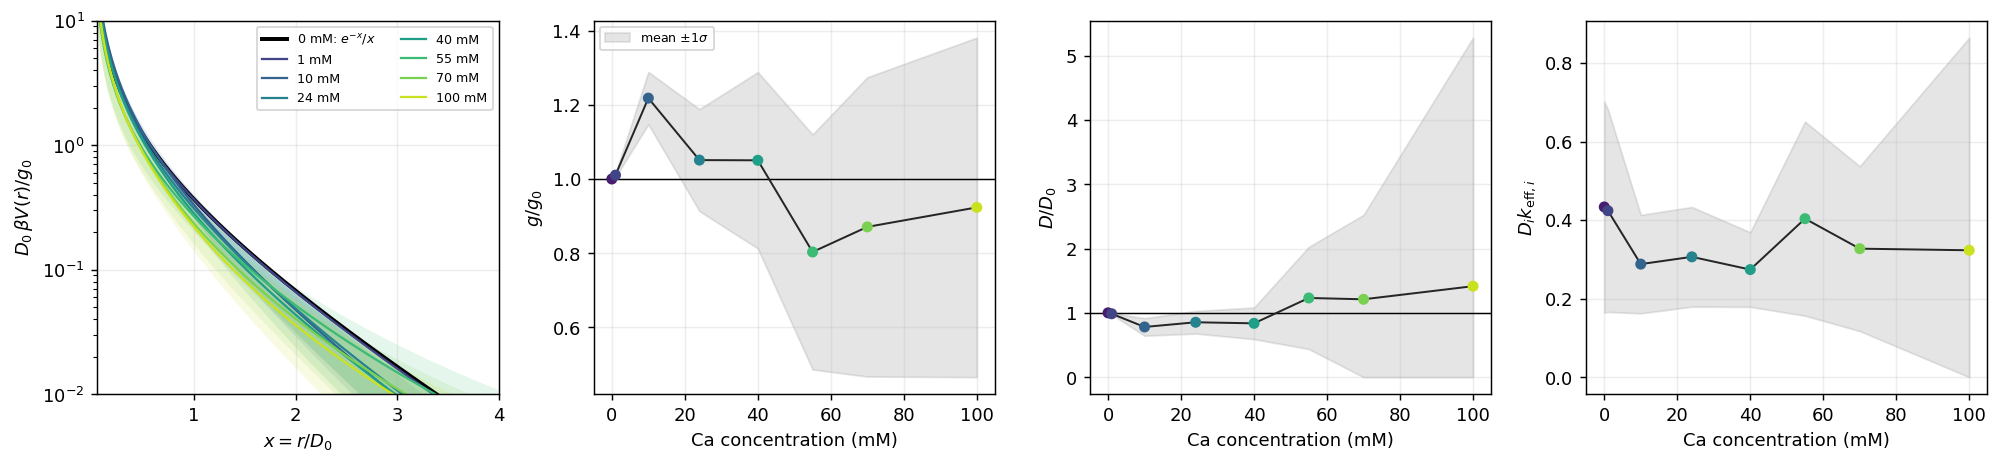

[{'concentration_mM': np.float64(0.0),
  'valid_reference_count': 289,
  'reference_count': 289,
  'common_valid_reference_count': 212,
  'g_over_g0_mean': np.float64(1.0),
  'g_over_g0_std': np.float64(0.0),
  'D_over_D0_mean': np.float64(1.0),
  'D_over_D0_std': np.float64(0.0),
  'D_k_eff_mean': np.float64(0.4333948888822754),
  'D_k_eff_std': np.float64(0.26859706456354254)},
 {'concentration_mM': np.float64(1.0),
  'valid_reference_count': 289,
  'reference_count': 289,
  'common_valid_reference_count': 212,
  'g_over_g0_mean': np.float64(1.0104081771501936),
  'g_over_g0_std': np.float64(0.005126442772351825),
  'D_over_D0_mean': np.float64(0.9855281843874169),
  'D_over_D0_std': np.float64(0.010811290315300775),
  'D_k_eff_mean': np.float64(0.4239318825432668),
  'D_k_eff_std': np.float64(0.2578493835395504)},
 {'concentration_mM': np.float64(10.0),
  'valid_reference_count': 284,
  'reference_count': 289,
  'common_valid_reference_count': 212,
  'g_over_g0_mean': np.float64(1.2

In [12]:
g0_grid = np.geomspace(*CONDITIONAL_G0_OVER_KREF_BOUNDS, CONDITIONAL_REFERENCE_GRID_SIZE)
d0_grid = np.geomspace(*CONDITIONAL_D0_KREF_BOUNDS, CONDITIONAL_REFERENCE_GRID_SIZE)
fit_salt = np.array([row.concentration_mM for row in fit_series])
if not np.allclose(fit_salt, salt):
    raise RuntimeError("fit-series and coefficient rows are not aligned")
target_k_eff = np.array([row.k_eff for row in fit_series])
target_ell_kref = CELL_LENGTH_MULTIPLIER * REFERENCE_K_EFF / target_k_eff
conditional_family = interaction.conditional_relative_yukawa_family(
    delta_c2, delta_c4, g0_grid, d0_grid,
    ell_kref=target_ell_kref,
    reference_ell_kref=CELL_LENGTH * REFERENCE_K_EFF,
)
envelope_sigma = CONDITIONAL_ENVELOPE_STANDARD_DEVIATIONS
reduced_distance = np.linspace(0.05, 8.0, 500)

# Use the same candidate reference subset at every concentration. This is
# essential: condition-specific validity masks would not define one coherent
# zero-salt-normalized comparison across the salt series.
common_valid = np.all(conditional_family.valid, axis=1)
if not np.any(common_valid):
    raise RuntimeError("No candidate zero-salt reference is valid for the full salt series; widen or revise the conditional reference bounds")
print(f"Conditional Yukawa plot uses {common_valid.sum()} common valid references out of {len(common_valid)} candidates")
reference_ddof = 1 if common_valid.sum() > 1 else 0

g_summary = np.full((len(salt), 2), np.nan)
d_summary = np.full((len(salt), 2), np.nan)
d_keff_summary = np.full((len(salt), 2), np.nan)
d_keff_family = (conditional_family.d_over_d0
                 * conditional_family.reference_d0_kref[:, None]
                 * target_k_eff[None, :] / REFERENCE_K_EFF)
valid_counts = conditional_family.valid.sum(axis=0)
for index in range(len(salt)):
    g_values = conditional_family.g_over_g0[common_valid, index]
    d_values = conditional_family.d_over_d0[common_valid, index]
    d_keff_values = d_keff_family[common_valid, index]
    g_summary[index] = (np.mean(g_values), np.std(g_values, ddof=reference_ddof))
    d_summary[index] = (np.mean(d_values), np.std(d_values, ddof=reference_ddof))
    d_keff_summary[index] = (np.mean(d_keff_values), np.std(d_keff_values, ddof=reference_ddof))

fig, axes = plt.subplots(1, 4, figsize=(15.5, 4))
potential_axis, g_axis, d_axis, d_keff_axis = axes
reference_profile = np.exp(-reduced_distance) / reduced_distance
potential_axis.plot(reduced_distance, reference_profile, color="k", lw=2.2, label="0 mM: $e^{-x}/x$")
for color, index, concentration in zip(colors, range(len(salt)), salt):
    if concentration == REFERENCE_SALT:
        continue
    profiles = interaction.normalized_yukawa_profile(
        reduced_distance, conditional_family.g_over_g0[common_valid, index],
        conditional_family.d_over_d0[common_valid, index],
    )
    profile_mean = np.mean(profiles, axis=0)
    profile_std = np.std(profiles, axis=0, ddof=reference_ddof)
    lower = np.maximum(profile_mean - envelope_sigma * profile_std, np.finfo(float).tiny)
    upper = profile_mean + envelope_sigma * profile_std
    potential_axis.fill_between(reduced_distance, lower, upper, color=color, alpha=0.13, linewidth=0)
    potential_axis.plot(reduced_distance, profile_mean, color=color, lw=1.25, label=f"{concentration:g} mM")

family_line_indices = np.flatnonzero(common_valid)
family_line_indices = family_line_indices[np.linspace(0, len(family_line_indices)-1, min(40, len(family_line_indices)), dtype=int)]
for axis, values, summary, ylabel, baseline in (
    (g_axis, conditional_family.g_over_g0, g_summary, r"$g/g_0$", 1.0),
    (d_axis, conditional_family.d_over_d0, d_summary, r"$D/D_0$", 1.0),
    (d_keff_axis, d_keff_family, d_keff_summary, r"$D_i k_{{\rm eff},i}$", None),
):
    if baseline is not None:
        axis.axhline(baseline, color="k", lw=0.8)
    # for family_index in family_line_indices:
    #     axis.plot(salt, values[family_index], color="0.55", alpha=0.12, lw=0.6)
    lower = np.maximum(summary[:, 0] - envelope_sigma * summary[:, 1], 0.0)
    upper = summary[:, 0] + envelope_sigma * summary[:, 1]
    axis.fill_between(salt, lower, upper, color="0.55", alpha=0.22, label=rf"mean $\pm{envelope_sigma:g}\sigma$")
    axis.plot(salt, summary[:, 0], color="0.15", lw=1.1)
    axis.scatter(salt, summary[:, 0], c=colors, s=26, zorder=3)
    axis.set(xlabel="Ca concentration (mM)", ylabel=ylabel)

potential_axis.set(xlabel=r"$x=r/D_0$", ylabel=r"$D_0\,\beta V(r)/g_0$", yscale="log", ylim=(1e-5, 40.0))
potential_axis.legend(fontsize=7, ncol=2)
potential_axis.set_ylim(1e-2, 10)
potential_axis.set_xlim(0.05, 4.0)
g_axis.legend(fontsize=7)
# fig.suptitle(
#     rf"Conditional reference family: $g_0/k_{{\rm ref}}\in[{CONDITIONAL_G0_OVER_KREF_BOUNDS[0]:g},{CONDITIONAL_G0_OVER_KREF_BOUNDS[1]:g}]$, "
#     rf"$D_0k_{{\rm ref}}\in[{CONDITIONAL_D0_KREF_BOUNDS[0]:g},{CONDITIONAL_D0_KREF_BOUNDS[1]:g}]$; {common_valid.sum()} common valid references",
#     fontsize=10,
# )
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(OUTPUT_DIR / "conditional_normalized_yukawa_comparison_inline.png")
plt.show()

conditional_rows = []
for reference_index, (g0_value, d0_value) in enumerate(zip(conditional_family.reference_g0_over_kref, conditional_family.reference_d0_kref)):
    for condition_index, concentration in enumerate(salt):
        conditional_rows.append({
            "concentration_mM": concentration,
            "reference_g0_over_kref": g0_value,
            "reference_D0_kref": d0_value,
            "valid": bool(conditional_family.valid[reference_index, condition_index]),
            "target_k_eff_over_kref": target_k_eff[condition_index] / REFERENCE_K_EFF,
            "target_ell_kref": target_ell_kref[condition_index],
            "g_over_g0": conditional_family.g_over_g0[reference_index, condition_index],
            "D_over_D0": conditional_family.d_over_d0[reference_index, condition_index],
            "D_k_eff": d_keff_family[reference_index, condition_index],
        })
with (OUTPUT_DIR / "conditional_yukawa_reference_family.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(conditional_rows[0]))
    writer.writeheader(); writer.writerows(conditional_rows)

conditional_summary_rows = [{
    "concentration_mM": concentration,
    "valid_reference_count": int(valid_counts[index]),
    "reference_count": len(conditional_family.valid),
    "common_valid_reference_count": int(common_valid.sum()),
    "g_over_g0_mean": g_summary[index, 0], "g_over_g0_std": g_summary[index, 1],
    "D_over_D0_mean": d_summary[index, 0], "D_over_D0_std": d_summary[index, 1],
    "D_k_eff_mean": d_keff_summary[index, 0], "D_k_eff_std": d_keff_summary[index, 1],
} for index, concentration in enumerate(salt)]
with (OUTPUT_DIR / "conditional_yukawa_reference_summary.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(conditional_summary_rows[0]))
    writer.writeheader(); writer.writerows(conditional_summary_rows)
conditional_summary_rows